# Train and Tune Random Forest Model

In [1]:
from pathlib import Path

import optuna.visualization as vis
import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.models.factory import Experiment
from src.models.random_forest import RandomForest
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_test_overlay, plot_val_overlay, plot_val_test_overlay
from src.runners import run_experiments
from src.utils import set_seed

In [2]:
cfg = Config(Path("../config/config.yaml"))
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TRIALS = cfg.runtime.trials
SPLITS = cfg.runtime.splits
rng = set_seed(SEED)

2025-08-30 14:36:24,474 - INFO - src.utils - Global random seed set to 42


In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")

In [4]:
MODEL_NAME = "random_forest"

experiments = [
    Experiment(
        name=MODEL_NAME,
        build=lambda horizon, seed: RandomForest(horizon=horizon, random_state=seed),
        include_sentiment=True
    )
]

In [5]:
results = run_experiments(df_full, Path(cfg.data.processed_dir), experiments, HORIZON, SEED, n_trials=TRIALS, n_splits=SPLITS)

2025-08-30 14:36:24,548 - INFO - ModelTrainer - Initialized ModelTrainer for model: random_forest
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
D:\IntelliJ\ml-stock-sent\.venv\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning: Argument ``constant_liar`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-08-30 14:36:26,085] A new study created in RDB with name: random_forest_study
2025-08-30 14:36:27,882 - INFO - ModelTrainer - Starting model tuning...
2025-08-30 14:36:27,889 - INFO - ModelTrainer - Starting model tuning...
2025-08-30 14:36:27,902 - INFO - ModelTrainer 

In [6]:
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

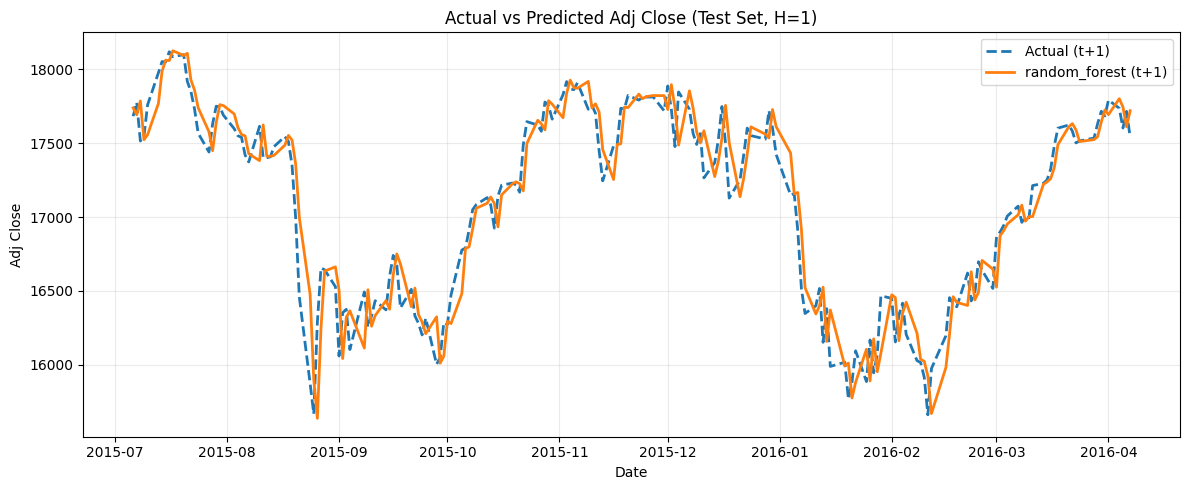

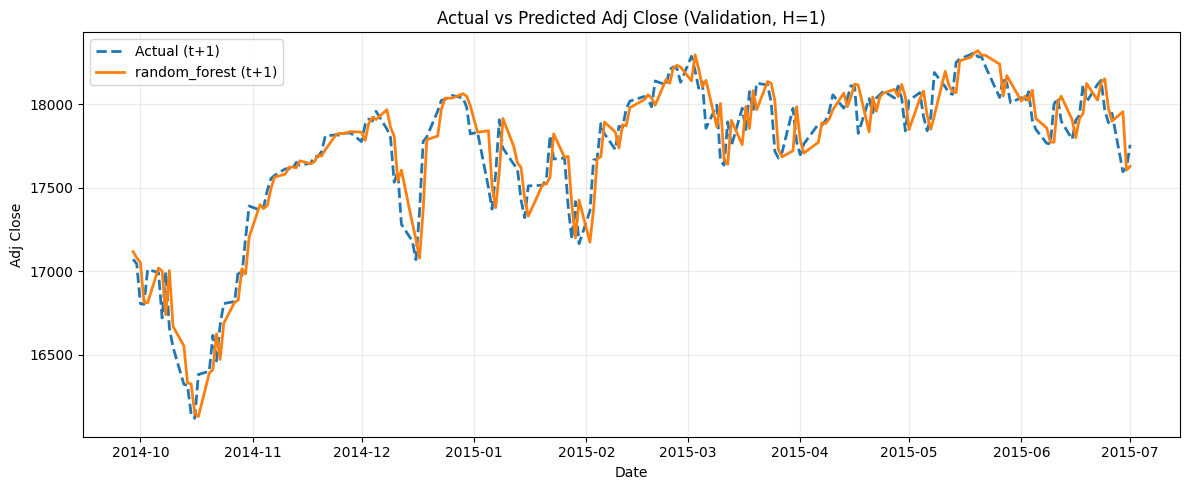

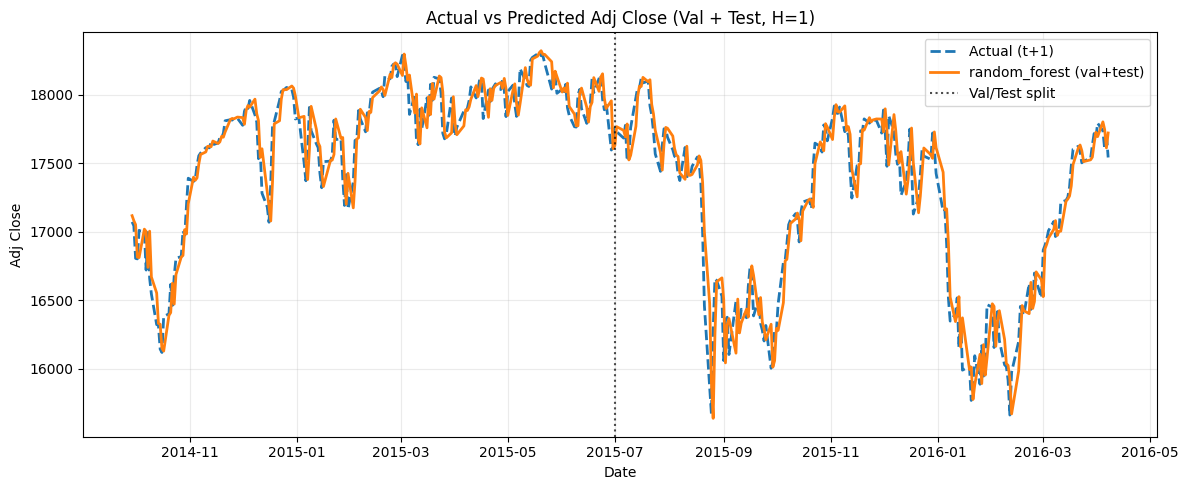

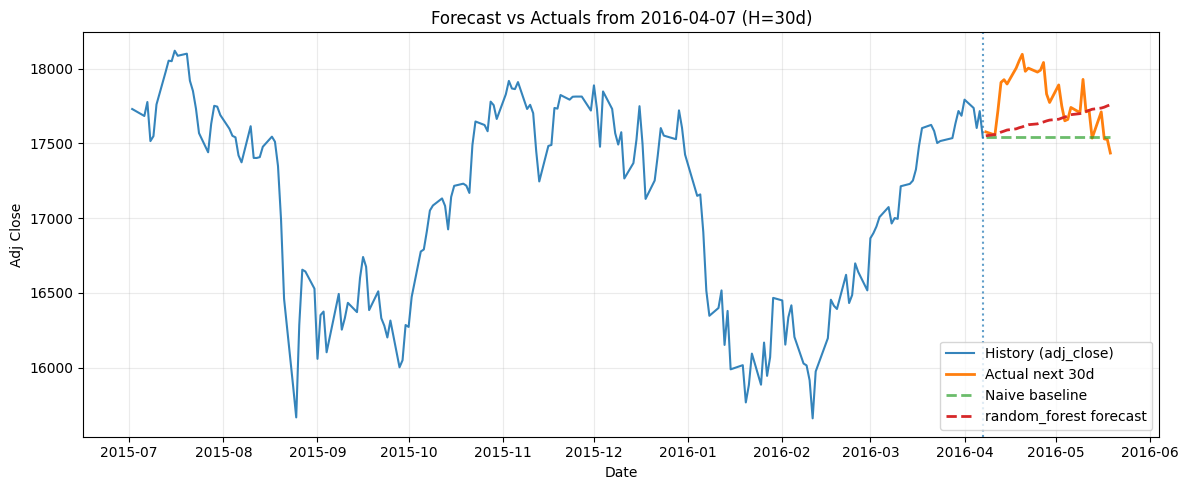

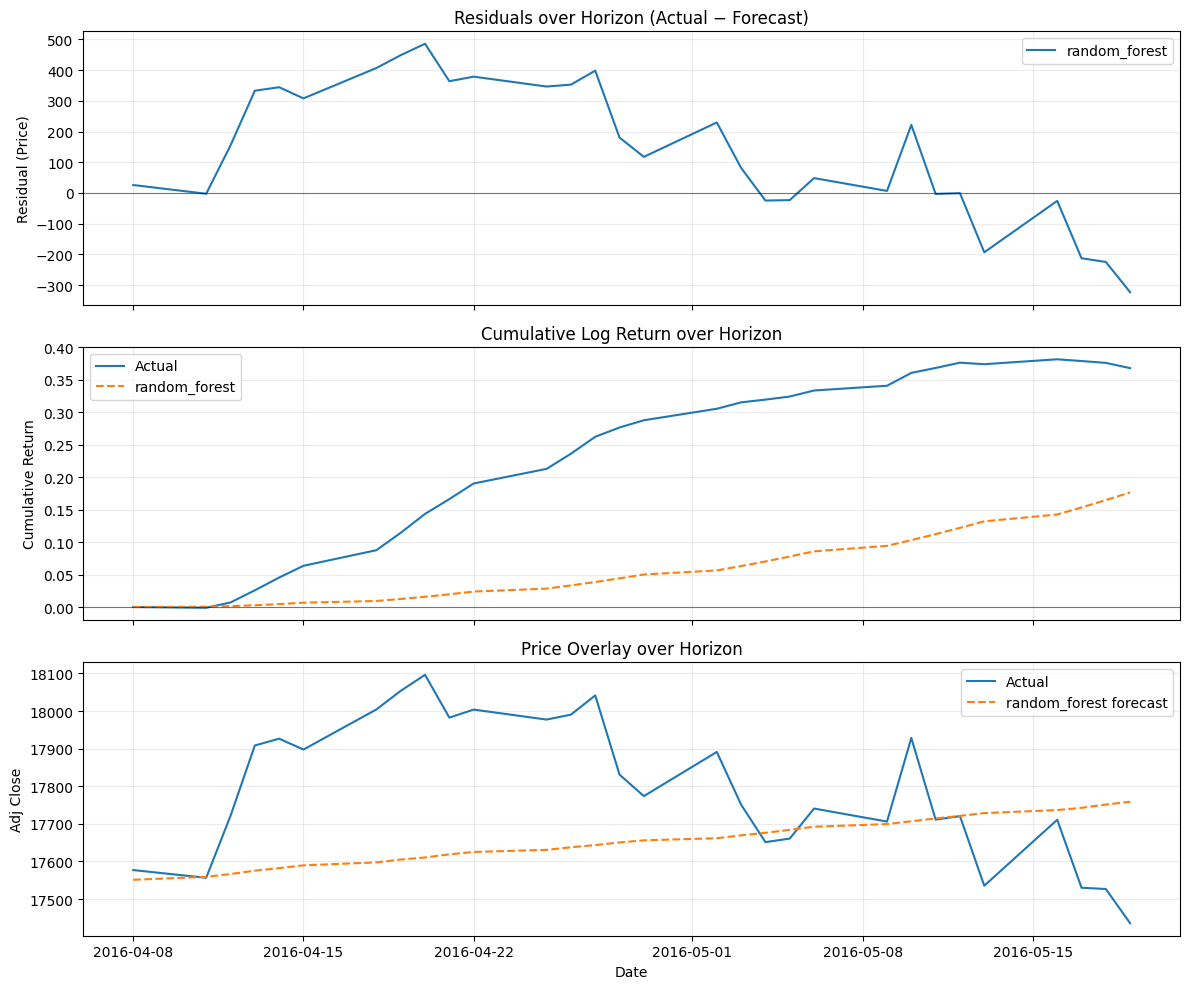

In [7]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close.png")
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val.png")
plot_val_test_overlay(val, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_actual_vs_predicted_adj_close_val_test.png")
plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast.png")
plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / f"{MODEL_NAME}_forecast_diagnostics.png")

In [8]:
pd.DataFrame(results[0]["best_params"], index=[0])

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,max_samples,criterion,random_state
0,200,6,13,10,log2,True,0.654816,squared_error,42


In [9]:
pd.DataFrame(results[0]["metrics"]["test"], index=[0])

,mae,mse,rmse,smape,r2
0,0.008277,0.000121,0.011,1.790777,-0.003557


In [16]:
study = results[0]["study"]

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()

In [11]:
from src.train import ModelTrainer
import pandas as pd
from pathlib import Path

model_path = Path(cfg.data.models_dir) / f"{MODEL_NAME}.pkl"
model, preprocessor, _, _ = ModelTrainer.load(str(model_path))

In [13]:
x_train_path = Path(cfg.data.processed_dir) / f"{MODEL_NAME}_X_train.parquet"
X_train = pd.read_parquet(x_train_path)

In [14]:
feat_names = preprocessor.get_feature_names_out(X_train.columns)
importances = pd.Series(model.model.feature_importances_, index=feat_names).sort_values(ascending=False)

In [15]:
def base_feature(n):
    tail = n.split("__")[-1]
    return tail.split("_", 1)[0]

grouped = importances.groupby(importances.index.map(base_feature)).sum().sort_values(ascending=False)
print(grouped.head(20))

lag       0.369614
emb       0.281236
ret       0.123481
log       0.069197
mom       0.055410
low       0.016411
open      0.015724
adj       0.014248
volume    0.012514
pos       0.012106
close     0.012023
high      0.008348
neu       0.005567
neg       0.003660
dow       0.000460
dtype: float64
